# 📊 Notebook 3 — Data Visualization

**Goal:** Understand patterns in the data visually before training.
Good visualization = better understanding of what the model needs to learn.

**Plots in this notebook:**
1. Refill distribution (class balance)
2. Sales by day of week
3. Sales by month (seasonal pattern)
4. Sales trend over years
5. Opening stock distribution on refill vs no-refill days
6. Closing stock distribution
7. Payment method breakdown
8. Weekly refill pattern heatmap

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['font.size']        = 11
COLORS = {'yes': '#e74c3c', 'no': '#2ecc71', 'blue': '#3498db', 'orange': '#e67e22'}

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
print(f'Loaded {len(df)} rows ✅')

Loaded 5189 rows ✅


## Plot 1 — Class Distribution (Refill vs No Refill)

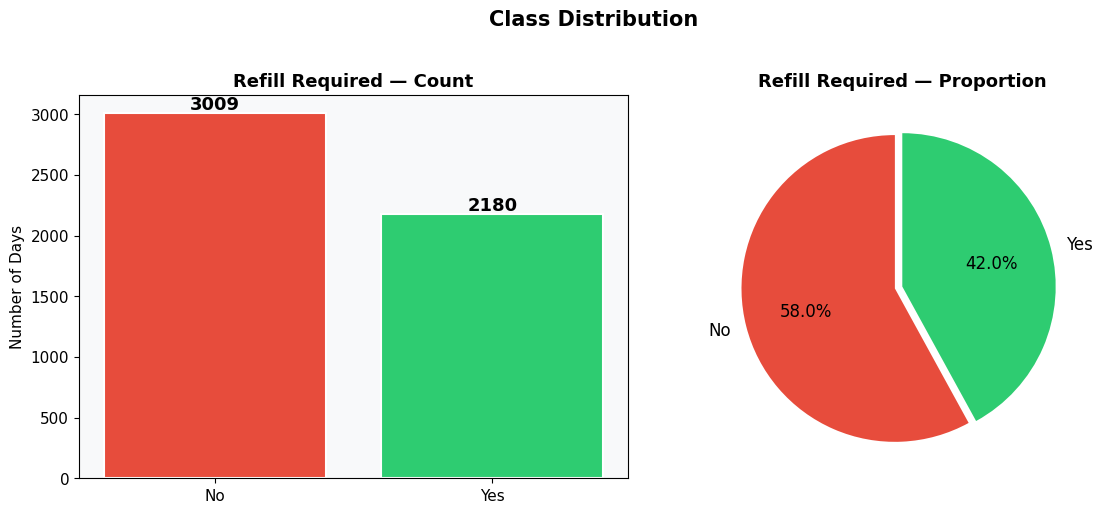

Refill days   : 2180 (42.0%)
No refill days: 3009 (58.0%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Refill_Required'].value_counts()

# Bar chart
axes[0].bar(counts.index, counts.values,
            color=[COLORS['yes'], COLORS['no']], edgecolor='white', linewidth=1.5)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Refill Required — Count', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Days')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=[COLORS['yes'], COLORS['no']],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0),
            textprops={'fontsize': 12})
axes[1].set_title('Refill Required — Proportion', fontweight='bold', fontsize=13)

plt.suptitle('Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/viz_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Refill days   : {counts.get("Yes", 0)} ({counts.get("Yes", 0)/len(df)*100:.1f}%)')
print(f'No refill days: {counts.get("No", 0)} ({counts.get("No", 0)/len(df)*100:.1f}%)')

## Plot 2 — Average Sales by Day of Week

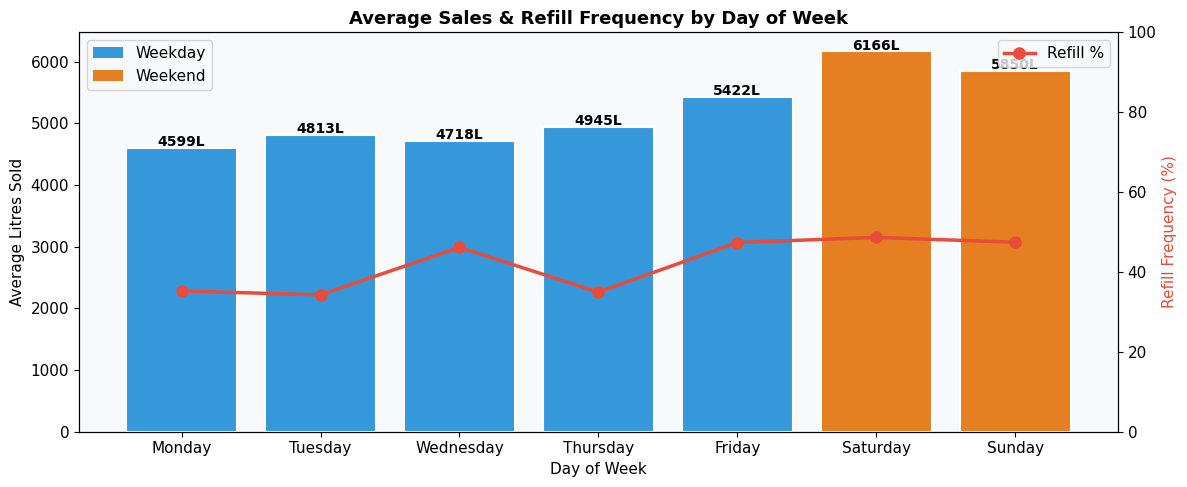

In [4]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('Day')['Total_Sold'].mean().reindex(day_order)
day_refill = df.groupby('Day')['Target'].mean().reindex(day_order) * 100

fig, ax1 = plt.subplots(figsize=(12, 5))

bar_colors = [COLORS['orange'] if d in ['Saturday','Sunday'] else COLORS['blue'] for d in day_order]
bars = ax1.bar(day_order, day_sales, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, day_sales):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:.0f}L', ha='center', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(day_order, day_refill, color=COLORS['yes'], marker='o',
         linewidth=2.5, markersize=8, label='Refill %')
ax2.set_ylabel('Refill Frequency (%)', color=COLORS['yes'])
ax2.set_ylim(0, 100)

ax1.set_title('Average Sales & Refill Frequency by Day of Week',
              fontweight='bold', fontsize=13)
ax1.set_ylabel('Average Litres Sold')
ax1.set_xlabel('Day of Week')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['blue'],   label='Weekday'),
    Patch(facecolor=COLORS['orange'], label='Weekend'),
]
ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../data/viz_02_sales_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 3 — Monthly Seasonal Pattern

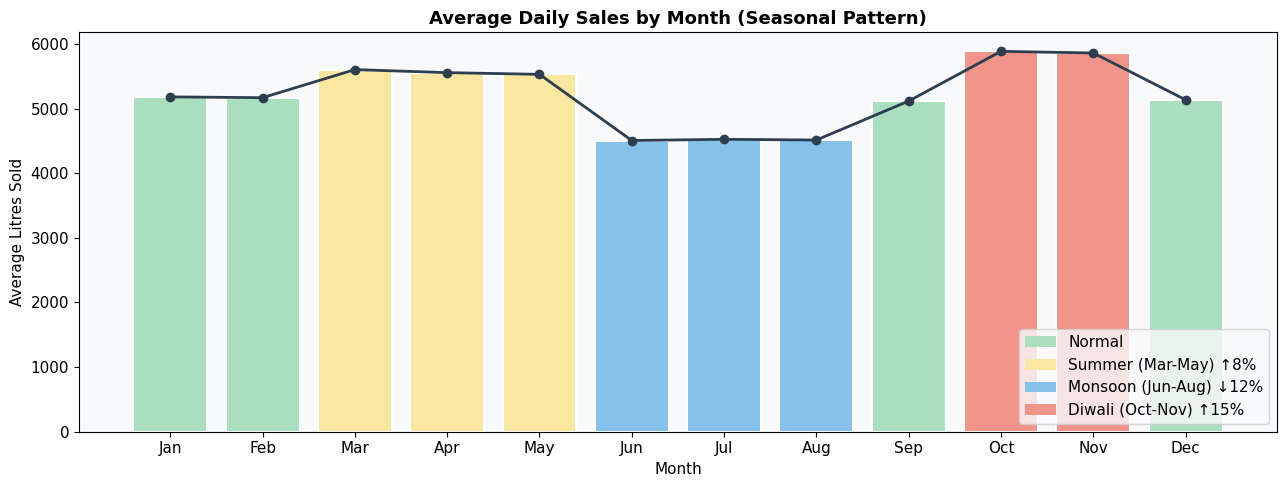

In [5]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_sales  = df.groupby('Month')['Total_Sold'].mean()
month_refill = df.groupby('Month')['Target'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 5))

month_colors = []
for m in range(1, 13):
    if m in [6,7,8]:   month_colors.append('#85c1e9')   # monsoon - blue
    elif m in [10,11]: month_colors.append('#f1948a')   # diwali - red
    elif m in [3,4,5]: month_colors.append('#f9e79f')   # summer - yellow
    else:              month_colors.append('#a9dfbf')   # normal - green

bars = ax.bar(month_names, month_sales, color=month_colors, edgecolor='white', linewidth=1.5)
ax.plot(month_names, month_sales, color='#2c3e50', marker='o',
        linewidth=2, markersize=6, zorder=5)

ax.set_title('Average Daily Sales by Month (Seasonal Pattern)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Average Litres Sold')
ax.set_xlabel('Month')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#a9dfbf', label='Normal'),
    Patch(facecolor='#f9e79f', label='Summer (Mar-May) ↑8%'),
    Patch(facecolor='#85c1e9', label='Monsoon (Jun-Aug) ↓12%'),
    Patch(facecolor='#f1948a', label='Diwali (Oct-Nov) ↑15%'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../data/viz_03_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Year-on-Year Sales Growth

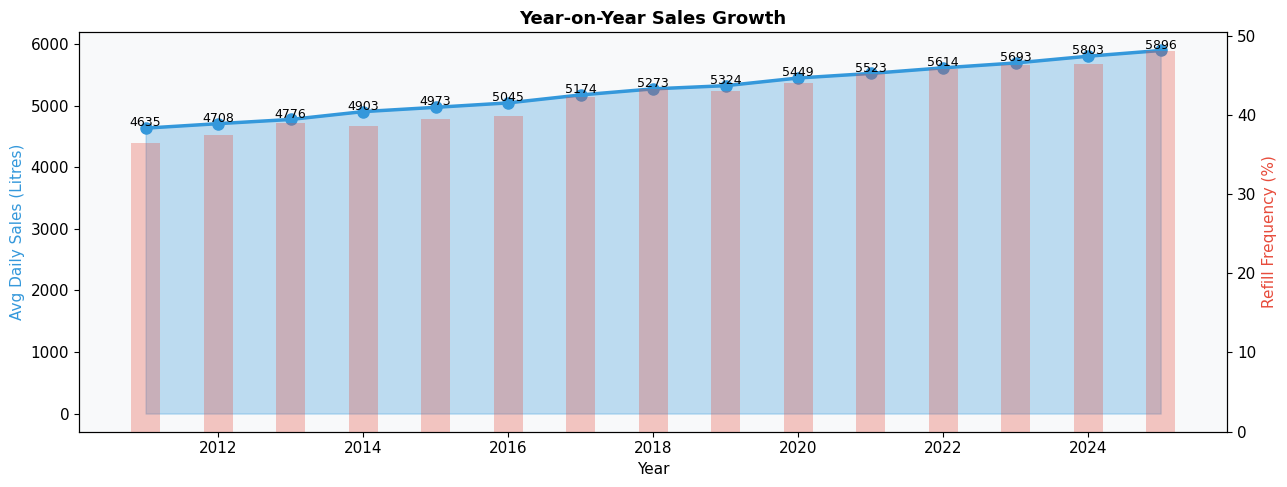

 Year   Avg_Sales  Refill_Days  Total_Days  Refill_Pct
 2011 4634.832877          133         365        36.4
 2012 4707.658470          137         366        37.4
 2013 4775.852055          142         365        38.9
 2014 4903.104110          141         365        38.6
 2015 4972.802740          144         365        39.5
 2016 5044.849727          146         366        39.9
 2017 5173.956164          154         365        42.2
 2018 5272.512329          158         365        43.3
 2019 5324.342466          157         365        43.0
 2020 5448.833333          161         366        44.0
 2021 5523.019178          165         365        45.2
 2022 5614.082192          167         365        45.8
 2023 5693.139726          169         365        46.3
 2024 5802.756831          170         366        46.4
 2025 5895.773333           36          75        48.0


In [6]:
yearly = df.groupby('Year').agg(
    Avg_Sales=('Total_Sold', 'mean'),
    Refill_Days=('Target', 'sum'),
    Total_Days=('Target', 'count')
).reset_index()
yearly['Refill_Pct'] = (yearly['Refill_Days'] / yearly['Total_Days'] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.fill_between(yearly['Year'], yearly['Avg_Sales'],
                 alpha=0.3, color=COLORS['blue'])
ax1.plot(yearly['Year'], yearly['Avg_Sales'],
         color=COLORS['blue'], marker='o', linewidth=2.5, markersize=8)
for _, row in yearly.iterrows():
    ax1.text(row['Year'], row['Avg_Sales'] + 30, f'{row["Avg_Sales"]:.0f}',
             ha='center', fontsize=9)

ax1.set_title('Year-on-Year Sales Growth', fontweight='bold', fontsize=13)
ax1.set_ylabel('Avg Daily Sales (Litres)', color=COLORS['blue'])
ax1.set_xlabel('Year')

ax2 = ax1.twinx()
ax2.bar(yearly['Year'], yearly['Refill_Pct'],
        alpha=0.3, color=COLORS['yes'], width=0.4)
ax2.set_ylabel('Refill Frequency (%)', color=COLORS['yes'])

plt.tight_layout()
plt.savefig('../data/viz_04_yearly_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print(yearly.to_string(index=False))

## Plot 5 — Opening Stock on Refill vs No-Refill Days

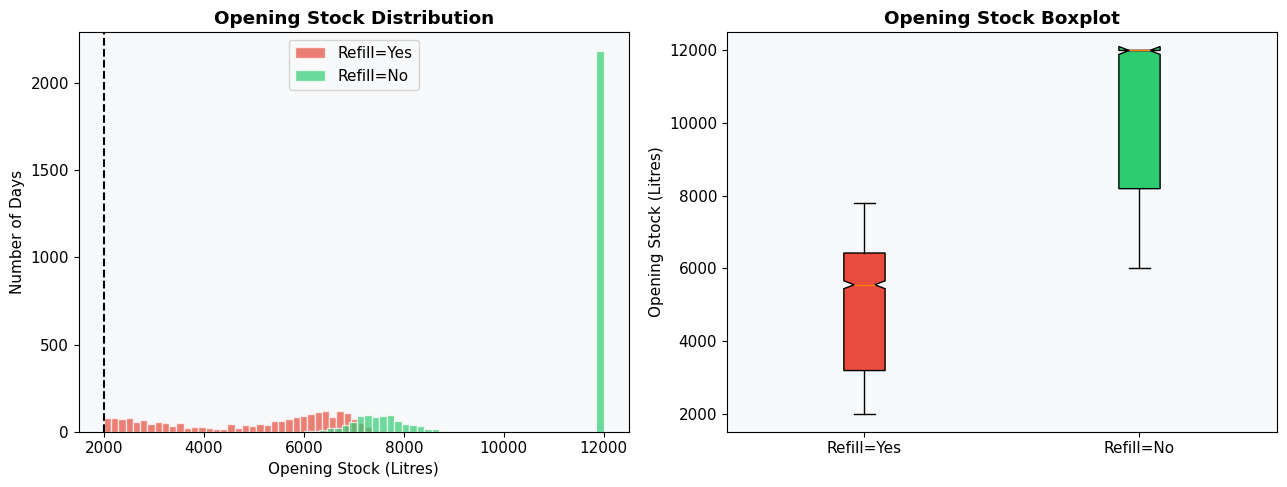

Mean Opening (Refill=Yes): 4958L
Mean Opening (Refill=No) : 10757L


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

refill_yes = df[df['Target'] == 1]['Opening_Stock']
refill_no  = df[df['Target'] == 0]['Opening_Stock']

axes[0].hist(refill_yes, bins=40, color=COLORS['yes'], alpha=0.7, label='Refill=Yes', edgecolor='white')
axes[0].hist(refill_no,  bins=40, color=COLORS['no'],  alpha=0.7, label='Refill=No',  edgecolor='white')
axes[0].set_title('Opening Stock Distribution', fontweight='bold')
axes[0].set_xlabel('Opening Stock (Litres)')
axes[0].set_ylabel('Number of Days')
axes[0].legend()
axes[0].axvline(2000, color='black', linestyle='--', linewidth=1.5, label='Refill Threshold')

# Box plot
data_to_plot = [refill_yes.values, refill_no.values]
bp = axes[1].boxplot(data_to_plot, labels=['Refill=Yes', 'Refill=No'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor(COLORS['yes'])
bp['boxes'][1].set_facecolor(COLORS['no'])
axes[1].set_title('Opening Stock Boxplot', fontweight='bold')
axes[1].set_ylabel('Opening Stock (Litres)')

plt.tight_layout()
plt.savefig('../data/viz_05_opening_stock.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean Opening (Refill=Yes): {refill_yes.mean():.0f}L')
print(f'Mean Opening (Refill=No) : {refill_no.mean():.0f}L')

## Plot 6 — Refill Heatmap by Day × Month

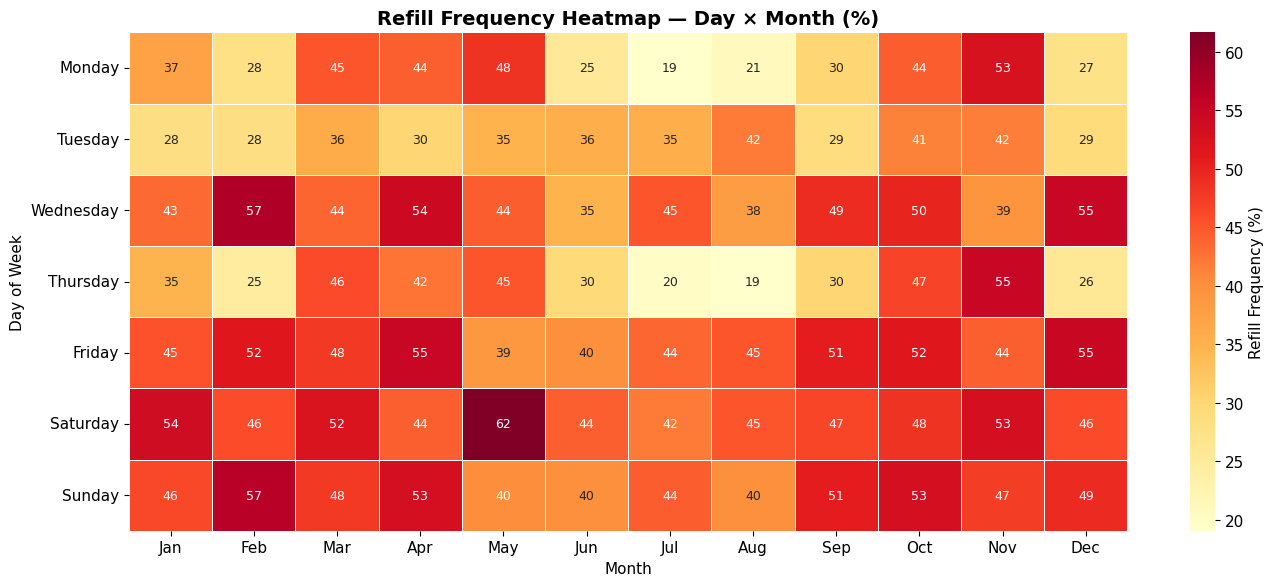

Darker = higher refill probability on that day/month combination


In [8]:
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

heatmap_data = df.groupby(['Day', 'Month'])['Target'].mean().unstack()
heatmap_data = heatmap_data.reindex(day_order)
heatmap_data.columns = month_names

plt.figure(figsize=(14, 6))
sns.heatmap(
    heatmap_data * 100, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5,
    cbar_kws={'label': 'Refill Frequency (%)'},
    annot_kws={'size': 9}
)
plt.title('Refill Frequency Heatmap — Day × Month (%)',
          fontweight='bold', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../data/viz_06_refill_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Darker = higher refill probability on that day/month combination')

## Plot 7 — Total Sales Distribution

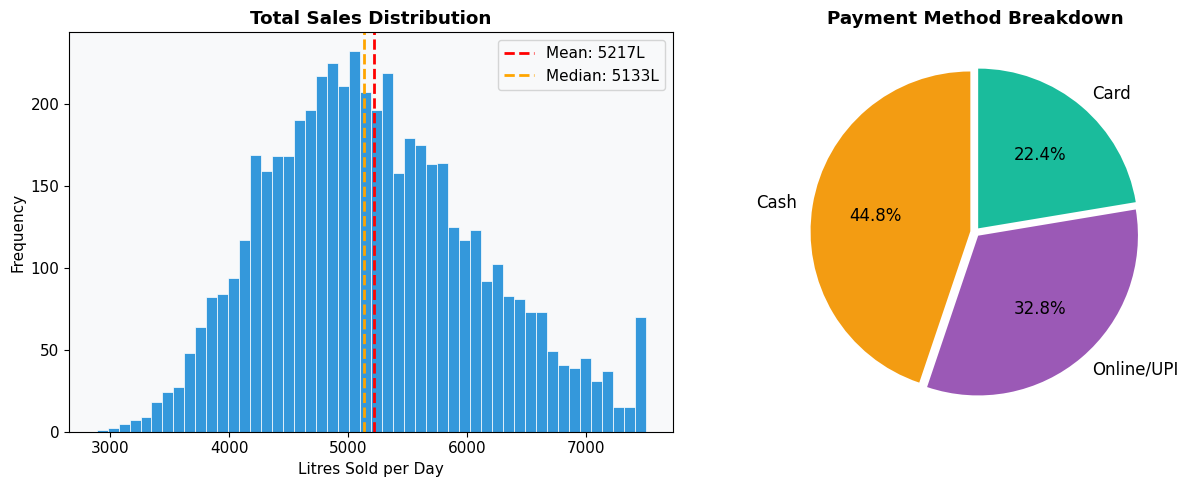

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['Total_Sold'], bins=50, color=COLORS['blue'],
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Total_Sold'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {df["Total_Sold"].mean():.0f}L')
axes[0].axvline(df['Total_Sold'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Median: {df["Total_Sold"].median():.0f}L')
axes[0].set_title('Total Sales Distribution', fontweight='bold')
axes[0].set_xlabel('Litres Sold per Day')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Payment breakdown pie
payment_means = df[['Cash','Online','Card']].mean()
axes[1].pie(payment_means, labels=['Cash','Online/UPI','Card'],
            colors=['#f39c12','#9b59b6','#1abc9c'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.03, 0.03, 0.03),
            textprops={'fontsize': 12})
axes[1].set_title('Payment Method Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/viz_07_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary of all plots generated

In [10]:
print('=== Visualization Summary ===')
print('All plots saved in data/ folder:')
plots = [
    ('viz_01_class_distribution.png',  'Class balance — Refill vs No Refill'),
    ('viz_02_sales_by_day.png',        'Sales pattern by day of week'),
    ('viz_03_seasonal_pattern.png',    'Monthly seasonal pattern'),
    ('viz_04_yearly_growth.png',       'Year-on-year growth trend'),
    ('viz_05_opening_stock.png',       'Opening stock on refill vs no-refill days'),
    ('viz_06_refill_heatmap.png',      'Refill heatmap day x month'),
    ('viz_07_sales_distribution.png',  'Sales distribution + payment breakdown'),
]
for fname, desc in plots:
    print(f'  ✅ {fname}')
    print(f'     → {desc}')

=== Visualization Summary ===
All plots saved in data/ folder:
  ✅ viz_01_class_distribution.png
     → Class balance — Refill vs No Refill
  ✅ viz_02_sales_by_day.png
     → Sales pattern by day of week
  ✅ viz_03_seasonal_pattern.png
     → Monthly seasonal pattern
  ✅ viz_04_yearly_growth.png
     → Year-on-year growth trend
  ✅ viz_05_opening_stock.png
     → Opening stock on refill vs no-refill days
  ✅ viz_06_refill_heatmap.png
     → Refill heatmap day x month
  ✅ viz_07_sales_distribution.png
     → Sales distribution + payment breakdown
